In [1]:
pip install mp-api


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.8/308.8 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.4/127.4 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.6 MB/s eta 0:00:00
   ━

/tmp/ipython-input-3564286858.py:10: DeprecationWarning: Accessing summary data through MPRester.summary is deprecated. Please use MPRester.materials.summary instead.
  docs = mpr.summary.search(


Retrieving SummaryDoc documents:   0%|          | 0/2 [00:00<?, ?it/s]

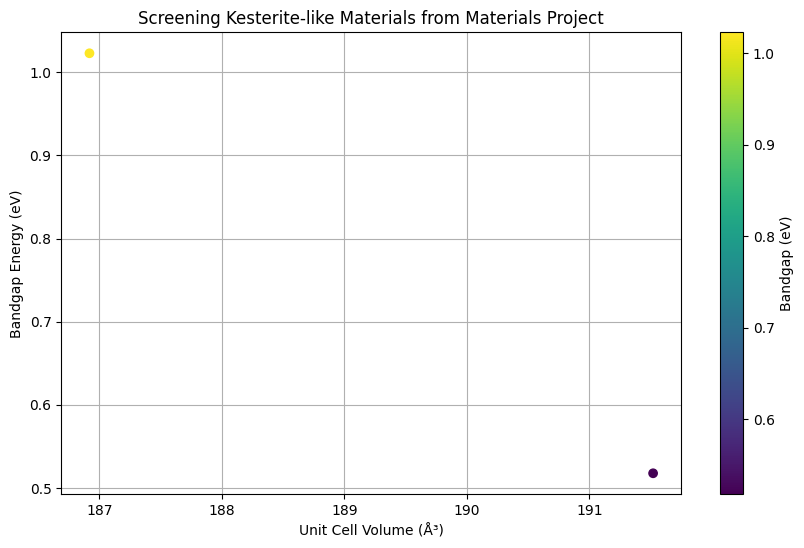

Successfully retrieved 2 materials!


In [2]:
from mp_api.client import MPRester
import pandas as pd
import matplotlib.pyplot as plt

# 1. Connect to Materials Project
with MPRester("H3mpVQ9JI0nCY1VbJljeqMxCkBSFVX8P") as mpr:

    # 2. Search for materials containing Cu, Zn, Sn, S (Kesterite elements)
    # We ask for the material_id, formula, bandgap, and volume (to estimate lattice)
    docs = mpr.summary.search(
        elements=["Cu", "Zn", "Sn", "S"],
        band_gap=(0.5, 2.5), # Filter for realistic solar bandgaps
        fields=["material_id", "formula_pretty", "band_gap", "volume"]
    )

# 3. Convert the results into a Dataframe
data_list = []
for doc in docs:
    data_list.append({
        'ID': doc.material_id,
        'Formula': doc.formula_pretty,
        'Bandgap': doc.band_gap,
        'Volume': doc.volume
    })

df = pd.DataFrame(data_list)

# 4. Create the Visualization
plt.figure(figsize=(10, 6))
plt.scatter(df['Volume'], df['Bandgap'], c=df['Bandgap'], cmap='viridis')
plt.colorbar(label='Bandgap (eV)')
plt.title('Screening Kesterite-like Materials from Materials Project')
plt.xlabel('Unit Cell Volume (Å³)')
plt.ylabel('Bandgap Energy (eV)')
plt.grid(True)
plt.show()

print(f"Successfully retrieved {len(df)} materials!")